In [35]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [36]:
# -----------------------------
# PARAMETERS
# -----------------------------
BATCH_SIZE = 24
IMG_SIZE = (224, 224)
EPOCHS = 30
AUTOTUNE = tf.data.AUTOTUNE
DATA_DIR = "./dataset_new"
NUM_MODELS = 5

In [37]:
# -----------------------------
# DATA PREPARATION
# -----------------------------
classes = sorted(os.listdir(DATA_DIR))
class_to_index = {c: i for i, c in enumerate(classes)}

image_paths, labels = [], []
for cls in classes:
    paths = glob(os.path.join(DATA_DIR, cls, "*"))
    image_paths.extend(paths)
    labels.extend([class_to_index[cls]] * len(paths))

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Classes:", classes)
print("Dataset size:", len(image_paths))

Classes: ['normal', 'osteoporosis']
Dataset size: 1945


In [38]:
def preprocess(path, label, augment=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=1, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.tile(img, [1, 1, 3])

    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.1)
        img = tf.image.random_contrast(img, 0.9, 1.1)

    return img, label


In [39]:
dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
dataset = dataset.shuffle(len(image_paths), seed=42)

train_size = int(0.5 * len(image_paths))
val_size = int(0.25 * len(image_paths))

train_ds = dataset.take(train_size)
val_test = dataset.skip(train_size)
val_ds = val_test.take(val_size)
test_ds = val_test.skip(val_size)

train_ds = train_ds.map(
    lambda x, y: preprocess(x, y, augment=True),
    num_parallel_calls=AUTOTUNE
).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = val_ds.map(
    preprocess,
    num_parallel_calls=AUTOTUNE
).batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = test_ds.map(
    preprocess,
    num_parallel_calls=AUTOTUNE
).batch(BATCH_SIZE).prefetch(AUTOTUNE)


In [40]:
def build_custom_cnn(seed):
    tf.random.set_seed(seed)

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(224,224,3)),

        tf.keras.layers.Conv2D(128, (8,8), strides=3, activation='relu'),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Conv2D(256, (5,5), padding="same", activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(3),

        tf.keras.layers.Conv2D(256, (3,3), padding="same", activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(256, (1,1), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(256, (1,1), activation='relu'),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Conv2D(512, (3,3), padding="same", activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2),

        tf.keras.layers.Conv2D(512, (3,3), padding="same", activation='relu'),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Conv2D(512, (3,3), padding="same", activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2),

        tf.keras.layers.Conv2D(512, (3,3), padding="same", activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2),

        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.01,
            momentum=0.9,
            nesterov=True
        ),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


In [41]:
# -----------------------------
# TRAINING 5 MODELS
# -----------------------------
histories = []
models = []

for i in range(NUM_MODELS):
    print(f"\nTraining model {i+1}")
    model = build_custom_cnn(seed=100+i)
    
    # Print summary for the first model only
    if i == 0:
        model.summary()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )

    model.save(f"cnn_model_{i}.h5")
    histories.append(history)
    models.append(model)



Training model 1


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 73, 73, 128)    │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 73, 73, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 73, 73, 256)    │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 73, 73, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 24, 24, 256)    │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 24, 24, 256)    │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 24, 24, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 24, 24, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 6, 6, 512)      │         2,04

 Total params: 10,101,377 (38.53 MB)

 Trainable params: 10,094,977 (38.51 MB)

...

Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 463s 11s/step - accuracy: 0.6481 - loss: 0.7773 - val_accuracy: 0.5103 - val_loss: 3.0460
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 303s 7s/step - accuracy: 0.6996 - loss: 0.6229 - val_accuracy: 0.4959 - val_loss: 0.7843
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 301s 7s/step - accuracy: 0.7356 - loss: 0.5394 - val_accuracy: 0.6811 - val_loss: 0.5765
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 301s 7s/step - accuracy: 0.7305 - loss: 0.5706 - val_accuracy: 0.6605 - val_loss: 0.6403
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 381s 9s/step - accuracy: 0.7315 - loss: 0.5355 - val_accuracy: 0.5988 - val_loss: 0.6194
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 310s 8s/step - accuracy: 0.7366 - loss: 0.5147 - val_accuracy: 0.7984 - val_loss: 0.4688
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 309s 8s/step - accuracy: 0.7788 - loss: 0.4848 - val_accuracy: 0.8189 - val_loss: 0.4414
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 325s 8s/step - accuracy: 0.7521 - loss: 0.4811 - val_accuracy: 0.7654 - 


Training model 2
Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 324s 8s/step - accuracy: 0.6224 - loss: 0.7884 - val_accuracy: 0.4877 - val_loss: 4.2553
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 309s 8s/step - accuracy: 0.7356 - loss: 0.5600 - val_accuracy: 0.6914 - val_loss: 0.6241
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 336s 8s/step - accuracy: 0.7325 - loss: 0.5667 - val_accuracy: 0.5905 - val_loss: 0.6978
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 306s 7s/step - accuracy: 0.7459 - loss: 0.5411 - val_accuracy: 0.6173 - val_loss: 0.6715
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 307s 8s/step - accuracy: 0.7870 - loss: 0.4751 - val_accuracy: 0.7305 - val_loss: 0.5491
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 308s 8s/step - accuracy: 0.7737 - loss: 0.5200 - val_accuracy: 0.8230 - val_loss: 0.4701
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 313s 8s/step - accuracy: 0.7747 - loss: 0.4703 - val_accuracy: 0.8313 - val_loss: 0.4210
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 309s 8s/step - accuracy: 0.7942 - loss: 0.4576 - val_ac


Training model 3
Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 300s 7s/step - accuracy: 0.6317 - loss: 0.7875 - val_accuracy: 0.4959 - val_loss: 4.2759
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 295s 7s/step - accuracy: 0.6996 - loss: 0.6098 - val_accuracy: 0.5226 - val_loss: 0.9115
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 299s 7s/step - accuracy: 0.7315 - loss: 0.5690 - val_accuracy: 0.6070 - val_loss: 0.6208
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 307s 7s/step - accuracy: 0.7428 - loss: 0.5258 - val_accuracy: 0.7407 - val_loss: 0.5585
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 311s 8s/step - accuracy: 0.7500 - loss: 0.5175 - val_accuracy: 0.7634 - val_loss: 0.5231
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 294s 7s/step - accuracy: 0.7819 - loss: 0.4949 - val_accuracy: 0.7099 - val_loss: 0.5883
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 294s 7s/step - accuracy: 0.7737 - loss: 0.4768 - val_accuracy: 0.7881 - val_loss: 0.4315
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 294s 7s/step - accuracy: 0.7737 - loss: 0.4720 - val_ac


Training model 4
Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 335s 8s/step - accuracy: 0.6368 - loss: 0.7822 - val_accuracy: 0.4979 - val_loss: 3.0256
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 309s 8s/step - accuracy: 0.7016 - loss: 0.6218 - val_accuracy: 0.5247 - val_loss: 0.7144
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 296s 7s/step - accuracy: 0.7387 - loss: 0.5468 - val_accuracy: 0.4918 - val_loss: 0.6885
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 298s 7s/step - accuracy: 0.7521 - loss: 0.5251 - val_accuracy: 0.6461 - val_loss: 0.6475
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 296s 7s/step - accuracy: 0.7695 - loss: 0.4819 - val_accuracy: 0.7160 - val_loss: 0.5912
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 296s 7s/step - accuracy: 0.7685 - loss: 0.5082 - val_accuracy: 0.6255 - val_loss: 0.6399
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 298s 7s/step - accuracy: 0.7706 - loss: 0.4984 - val_accuracy: 0.7551 - val_loss: 0.4772
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 295s 7s/step - accuracy: 0.7767 - loss: 0.4835 - val_ac


Training model 5
Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 305s 7s/step - accuracy: 0.6440 - loss: 0.7617 - val_accuracy: 0.5329 - val_loss: 3.8304
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 295s 7s/step - accuracy: 0.7078 - loss: 0.6013 - val_accuracy: 0.4691 - val_loss: 1.2425
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 295s 7s/step - accuracy: 0.7202 - loss: 0.5414 - val_accuracy: 0.6605 - val_loss: 0.6421
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 295s 7s/step - accuracy: 0.7582 - loss: 0.5238 - val_accuracy: 0.7469 - val_loss: 0.5360
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 301s 7s/step - accuracy: 0.7449 - loss: 0.5097 - val_accuracy: 0.7222 - val_loss: 0.5708
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 297s 7s/step - accuracy: 0.7479 - loss: 0.4979 - val_accuracy: 0.7572 - val_loss: 0.5473
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 296s 7s/step - accuracy: 0.7942 - loss: 0.4496 - val_accuracy: 0.7901 - val_loss: 0.4231
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 294s 7s/step - accuracy: 0.7767 - loss: 0.4601 - val_ac

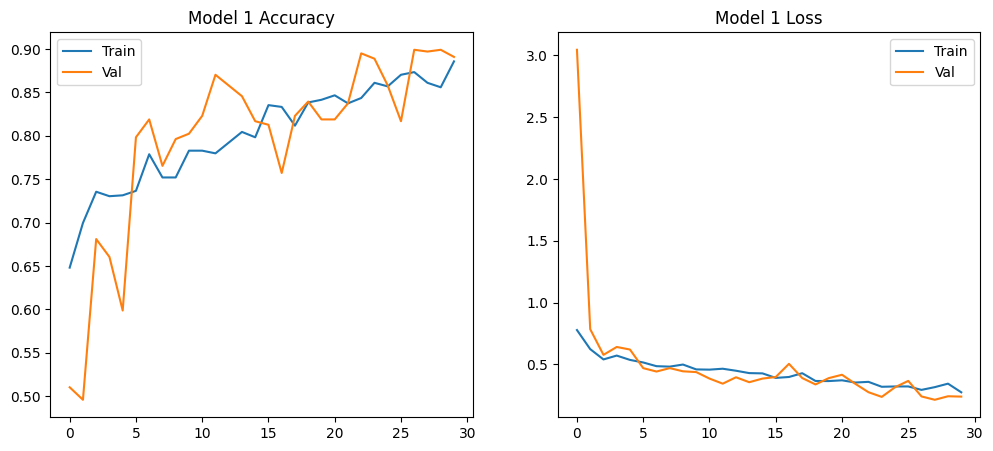

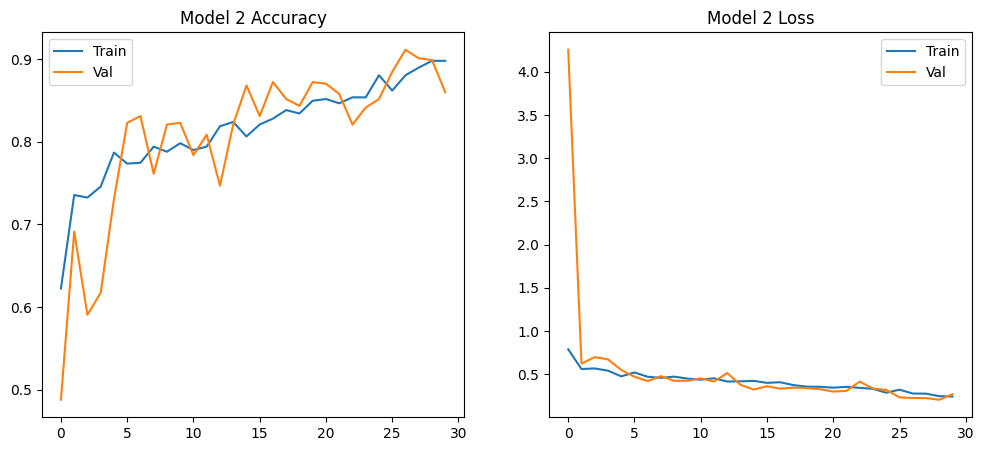

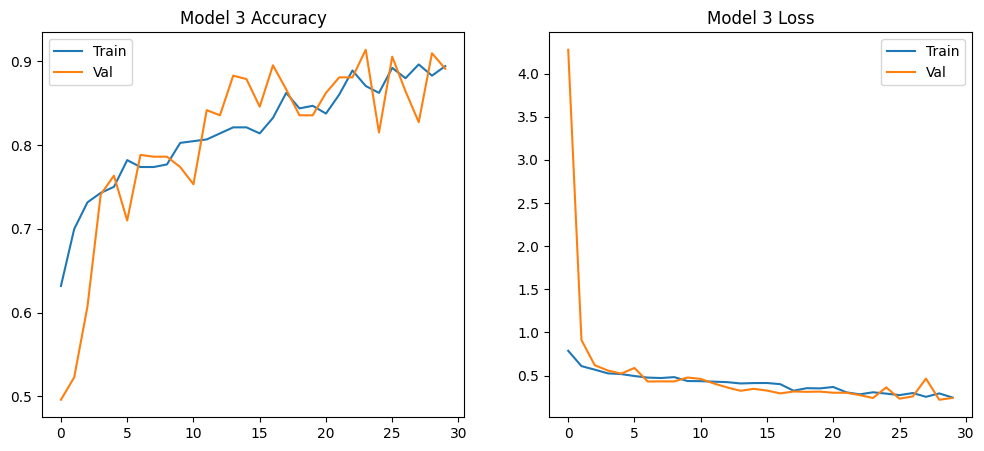

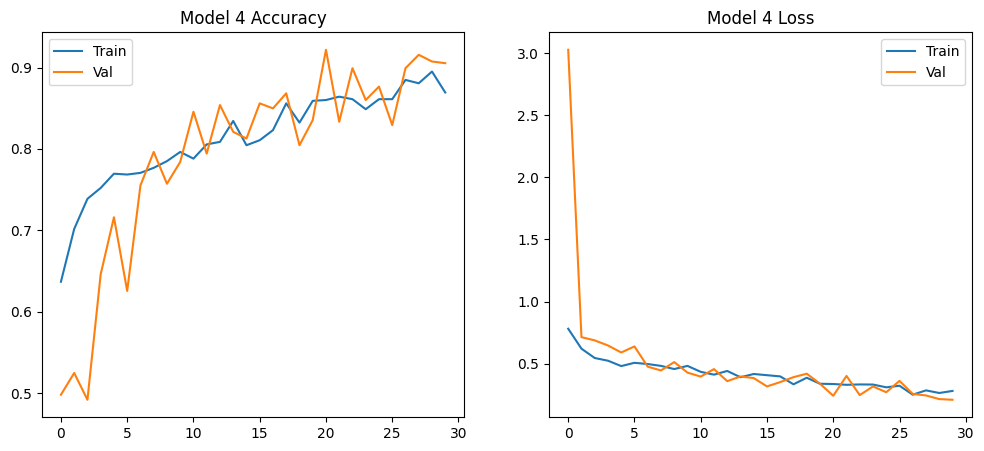

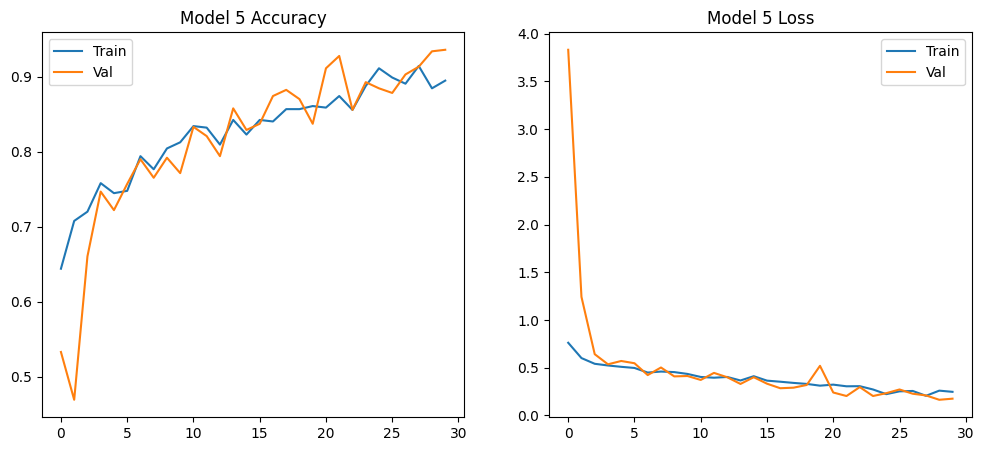

In [42]:
# -----------------------------
# PLOT TRAINING HISTORY
# -----------------------------
def plot_history(history, idx):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(acc, label='Train')
    plt.plot(val_acc, label='Val')
    plt.title(f'Model {idx} Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(loss, label='Train')
    plt.plot(val_loss, label='Val')
    plt.title(f'Model {idx} Loss')
    plt.legend()

    plt.show()

for i, h in enumerate(histories):
    plot_history(h, i+1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


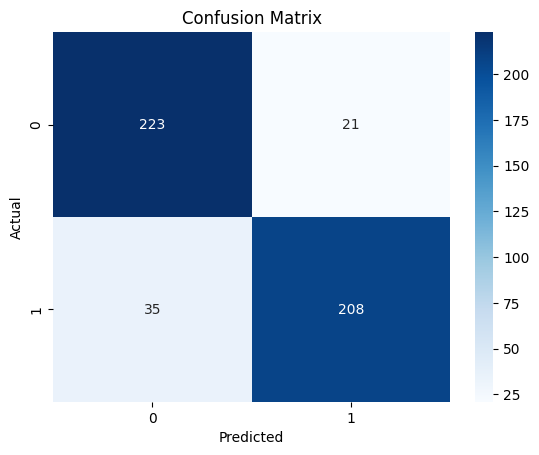

              precision    recall  f1-score   support

           0       0.86      0.91      0.89       244
           1       0.91      0.86      0.88       243

    accuracy                           0.89       487
   macro avg       0.89      0.88      0.88       487
weighted avg       0.89      0.89      0.88       487



In [44]:
y_true = []
y_pred = []

for imgs, labels in test_ds:
    preds = models[1].predict(imgs)
    y_true.extend(labels.numpy())
    y_pred.extend((preds > 0.5).astype(int))

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred))



Threshold: 0.3


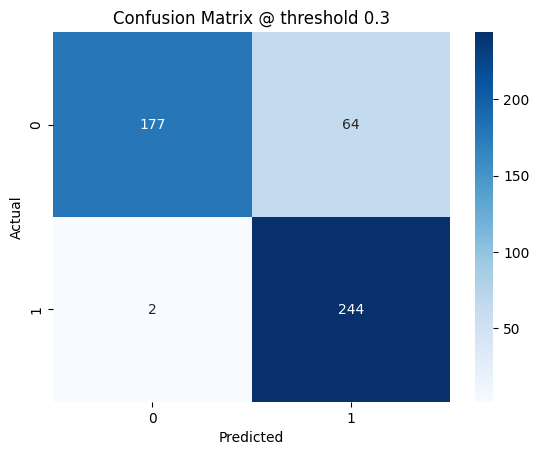

              precision    recall  f1-score   support

           0       0.99      0.73      0.84       241
           1       0.79      0.99      0.88       246

    accuracy                           0.86       487
   macro avg       0.89      0.86      0.86       487
weighted avg       0.89      0.86      0.86       487


Threshold: 0.35


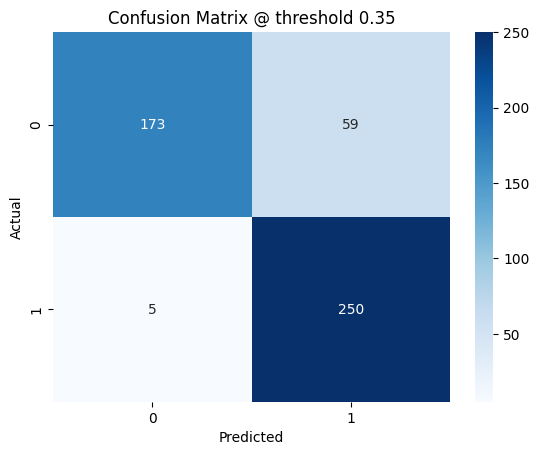

              precision    recall  f1-score   support

           0       0.97      0.75      0.84       232
           1       0.81      0.98      0.89       255

    accuracy                           0.87       487
   macro avg       0.89      0.86      0.87       487
weighted avg       0.89      0.87      0.87       487


Threshold: 0.4


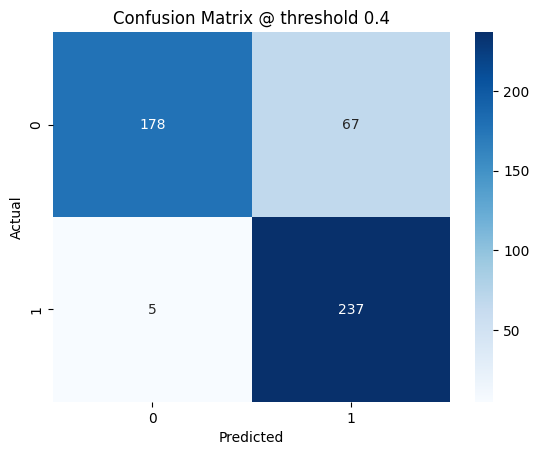

              precision    recall  f1-score   support

           0       0.97      0.73      0.83       245
           1       0.78      0.98      0.87       242

    accuracy                           0.85       487
   macro avg       0.88      0.85      0.85       487
weighted avg       0.88      0.85      0.85       487


Threshold: 0.45


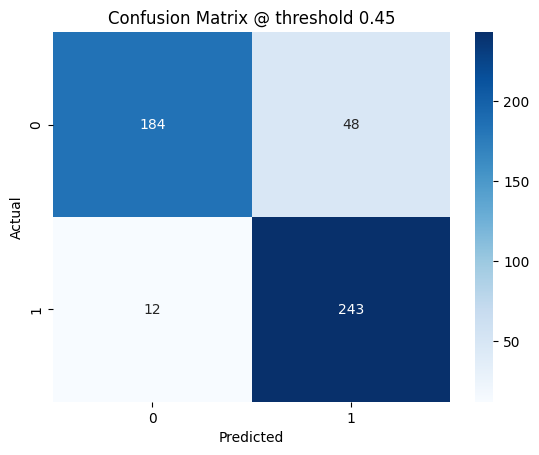

              precision    recall  f1-score   support

           0       0.94      0.79      0.86       232
           1       0.84      0.95      0.89       255

    accuracy                           0.88       487
   macro avg       0.89      0.87      0.87       487
weighted avg       0.88      0.88      0.88       487


Threshold: 0.5


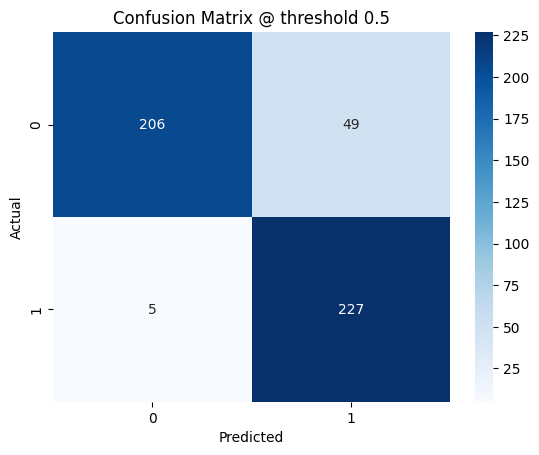

              precision    recall  f1-score   support

           0       0.98      0.81      0.88       255
           1       0.82      0.98      0.89       232

    accuracy                           0.89       487
   macro avg       0.90      0.89      0.89       487
weighted avg       0.90      0.89      0.89       487


Threshold: 0.55


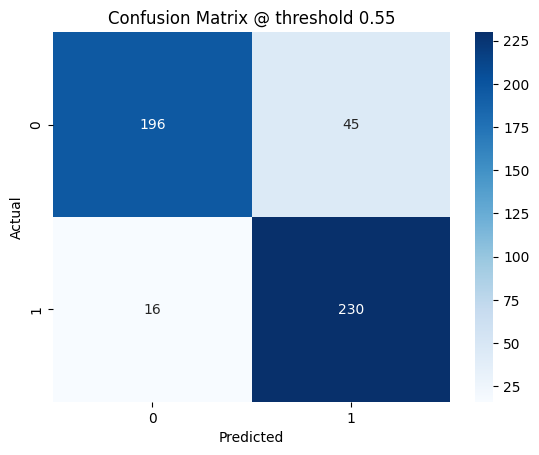

              precision    recall  f1-score   support

           0       0.92      0.81      0.87       241
           1       0.84      0.93      0.88       246

    accuracy                           0.87       487
   macro avg       0.88      0.87      0.87       487
weighted avg       0.88      0.87      0.87       487


Threshold: 0.6


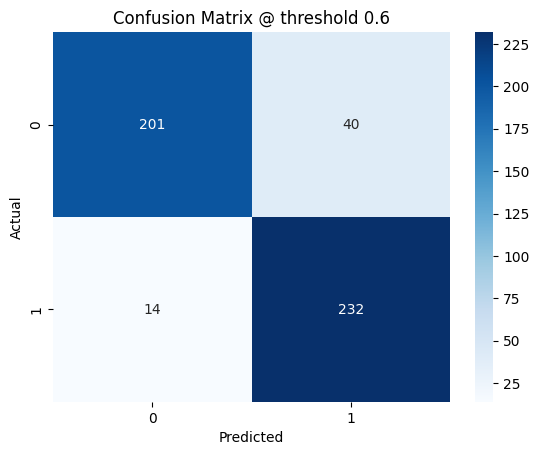

              precision    recall  f1-score   support

           0       0.93      0.83      0.88       241
           1       0.85      0.94      0.90       246

    accuracy                           0.89       487
   macro avg       0.89      0.89      0.89       487
weighted avg       0.89      0.89      0.89       487


Threshold: 0.65


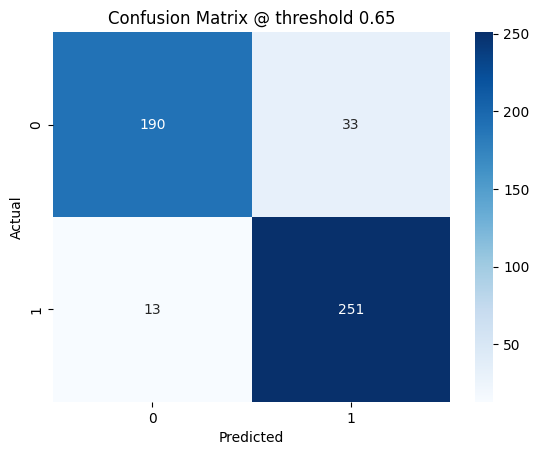

              precision    recall  f1-score   support

           0       0.94      0.85      0.89       223
           1       0.88      0.95      0.92       264

    accuracy                           0.91       487
   macro avg       0.91      0.90      0.90       487
weighted avg       0.91      0.91      0.91       487


Threshold: 0.7


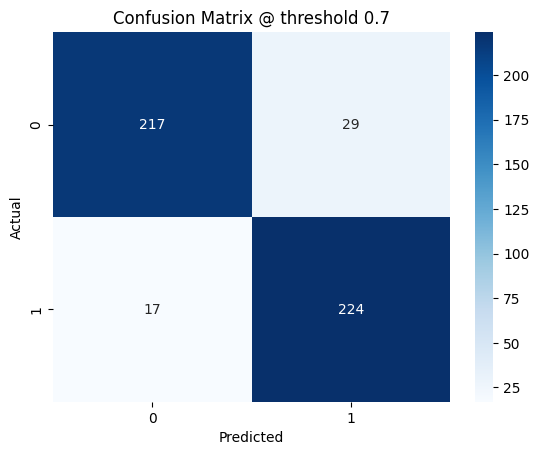

              precision    recall  f1-score   support

           0       0.93      0.88      0.90       246
           1       0.89      0.93      0.91       241

    accuracy                           0.91       487
   macro avg       0.91      0.91      0.91       487
weighted avg       0.91      0.91      0.91       487



In [ ]:
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]

for t in thresholds:

    y_true = []  
    y_pred = []

    for imgs, labels in test_ds:
        preds = models[0].predict(imgs, verbose=0)
        preds = preds.ravel()  # ✅ IMPORTANT

        y_true.extend(labels.numpy())
        y_pred.extend((preds >= t).astype(int))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    cm = confusion_matrix(y_true, y_pred)

    print(f"\nThreshold: {t}")
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix @ threshold {t}")
    plt.show()

    print(classification_report(y_true, y_pred))



Threshold: 0.3


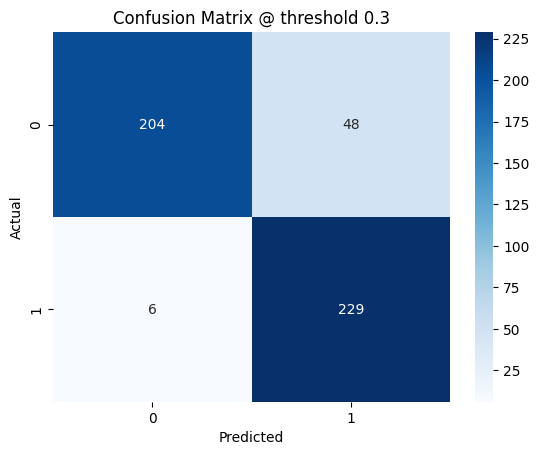

              precision    recall  f1-score   support

           0       0.97      0.81      0.88       252
           1       0.83      0.97      0.89       235

    accuracy                           0.89       487
   macro avg       0.90      0.89      0.89       487
weighted avg       0.90      0.89      0.89       487


Threshold: 0.35


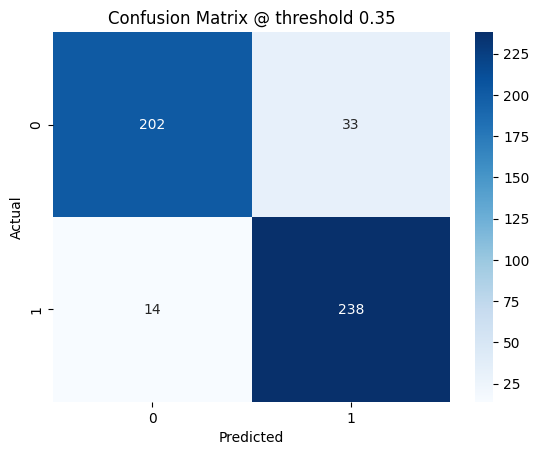

              precision    recall  f1-score   support

           0       0.94      0.86      0.90       235
           1       0.88      0.94      0.91       252

    accuracy                           0.90       487
   macro avg       0.91      0.90      0.90       487
weighted avg       0.91      0.90      0.90       487


Threshold: 0.4


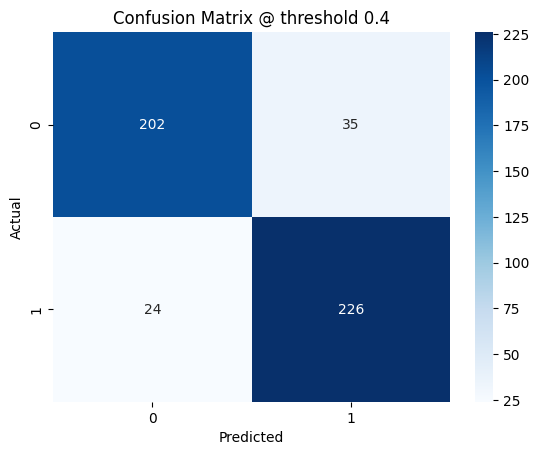

              precision    recall  f1-score   support

           0       0.89      0.85      0.87       237
           1       0.87      0.90      0.88       250

    accuracy                           0.88       487
   macro avg       0.88      0.88      0.88       487
weighted avg       0.88      0.88      0.88       487


Threshold: 0.45


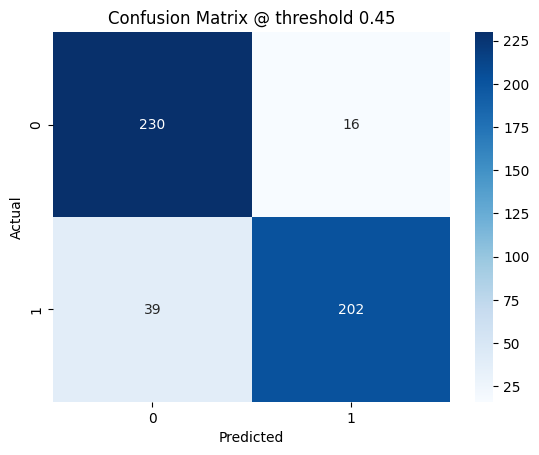

              precision    recall  f1-score   support

           0       0.86      0.93      0.89       246
           1       0.93      0.84      0.88       241

    accuracy                           0.89       487
   macro avg       0.89      0.89      0.89       487
weighted avg       0.89      0.89      0.89       487


Threshold: 0.5


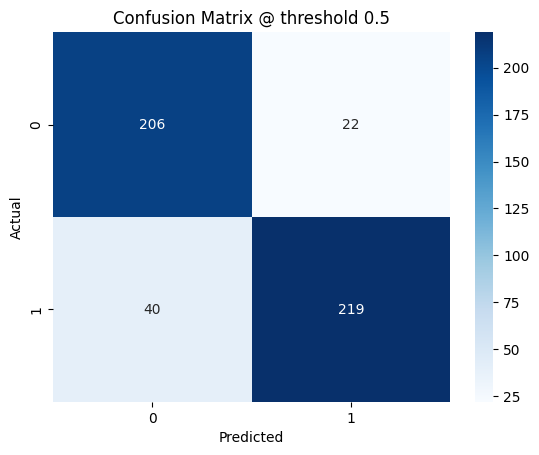

              precision    recall  f1-score   support

           0       0.84      0.90      0.87       228
           1       0.91      0.85      0.88       259

    accuracy                           0.87       487
   macro avg       0.87      0.87      0.87       487
weighted avg       0.88      0.87      0.87       487


Threshold: 0.55


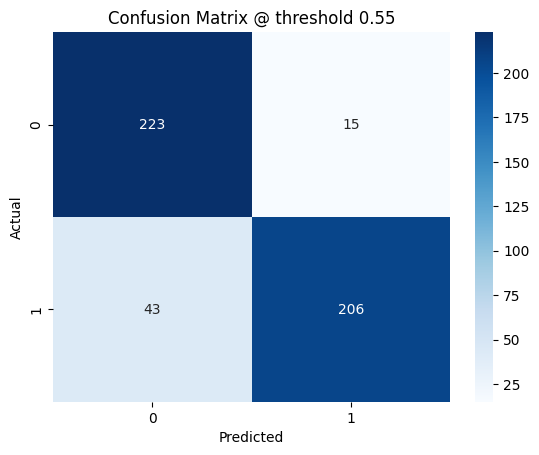

              precision    recall  f1-score   support

           0       0.84      0.94      0.88       238
           1       0.93      0.83      0.88       249

    accuracy                           0.88       487
   macro avg       0.89      0.88      0.88       487
weighted avg       0.89      0.88      0.88       487


Threshold: 0.6


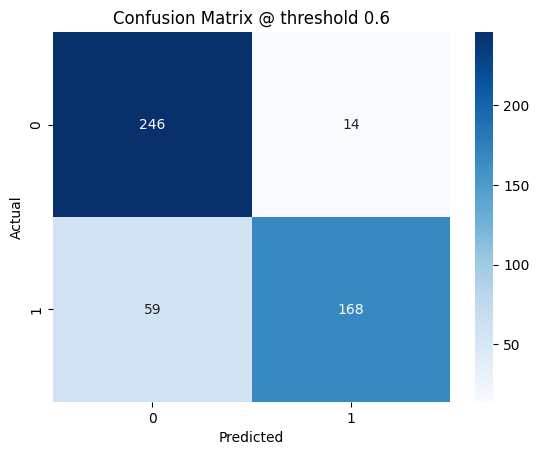

              precision    recall  f1-score   support

           0       0.81      0.95      0.87       260
           1       0.92      0.74      0.82       227

    accuracy                           0.85       487
   macro avg       0.86      0.84      0.85       487
weighted avg       0.86      0.85      0.85       487


Threshold: 0.65


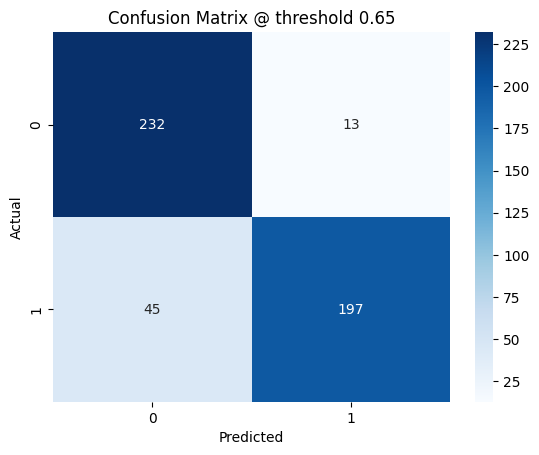

              precision    recall  f1-score   support

           0       0.84      0.95      0.89       245
           1       0.94      0.81      0.87       242

    accuracy                           0.88       487
   macro avg       0.89      0.88      0.88       487
weighted avg       0.89      0.88      0.88       487


Threshold: 0.7


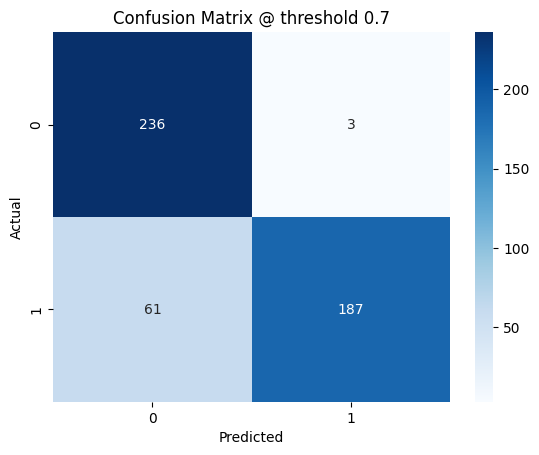

              precision    recall  f1-score   support

           0       0.79      0.99      0.88       239
           1       0.98      0.75      0.85       248

    accuracy                           0.87       487
   macro avg       0.89      0.87      0.87       487
weighted avg       0.89      0.87      0.87       487



In [53]:
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]

for t in thresholds:

    y_true = []  
    y_pred = []

    for imgs, labels in test_ds:
        preds = models[1].predict(imgs, verbose=0)
        preds = preds.ravel()  # ✅ IMPORTANT

        y_true.extend(labels.numpy())
        y_pred.extend((preds >= t).astype(int))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    cm = confusion_matrix(y_true, y_pred)

    print(f"\nThreshold: {t}")
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix @ threshold {t}")
    plt.show()

    print(classification_report(y_true, y_pred))



Threshold: 0.3


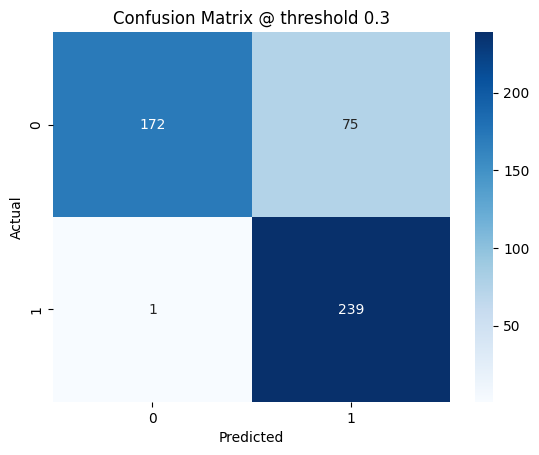

              precision    recall  f1-score   support

           0       0.99      0.70      0.82       247
           1       0.76      1.00      0.86       240

    accuracy                           0.84       487
   macro avg       0.88      0.85      0.84       487
weighted avg       0.88      0.84      0.84       487


Threshold: 0.35


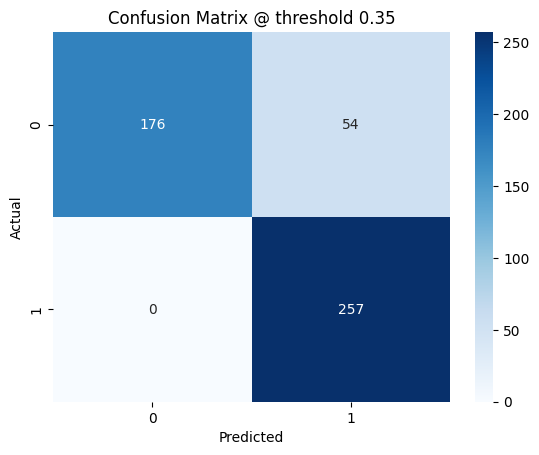

              precision    recall  f1-score   support

           0       1.00      0.77      0.87       230
           1       0.83      1.00      0.90       257

    accuracy                           0.89       487
   macro avg       0.91      0.88      0.89       487
weighted avg       0.91      0.89      0.89       487


Threshold: 0.4


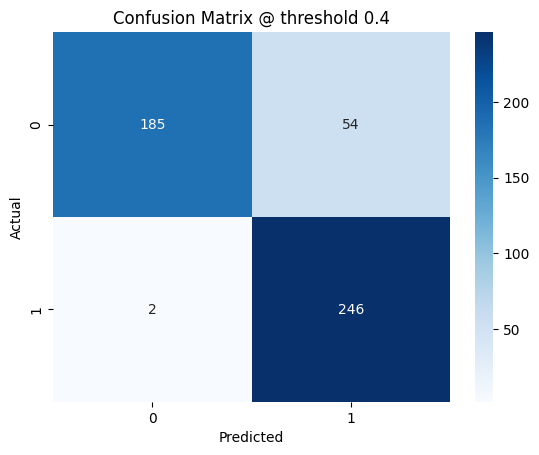

              precision    recall  f1-score   support

           0       0.99      0.77      0.87       239
           1       0.82      0.99      0.90       248

    accuracy                           0.89       487
   macro avg       0.90      0.88      0.88       487
weighted avg       0.90      0.89      0.88       487


Threshold: 0.45


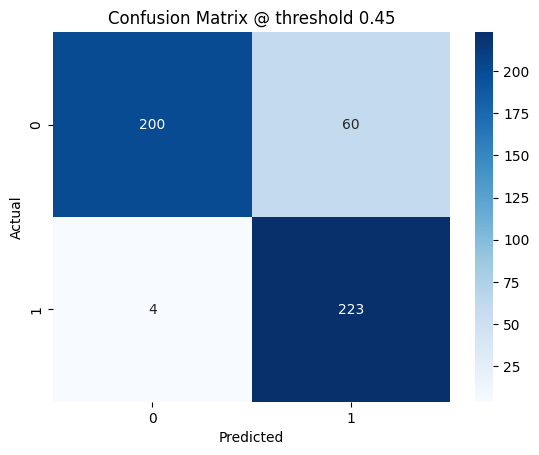

              precision    recall  f1-score   support

           0       0.98      0.77      0.86       260
           1       0.79      0.98      0.87       227

    accuracy                           0.87       487
   macro avg       0.88      0.88      0.87       487
weighted avg       0.89      0.87      0.87       487


Threshold: 0.5


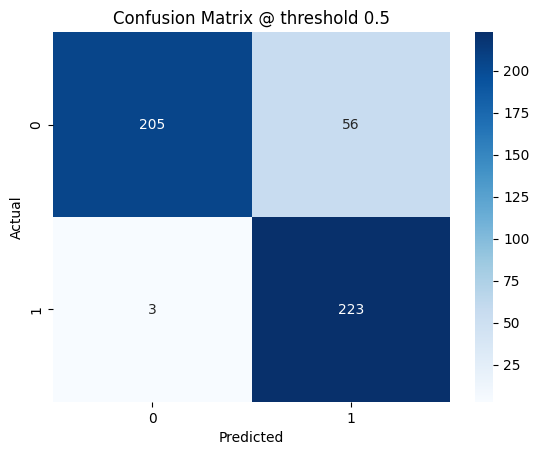

              precision    recall  f1-score   support

           0       0.99      0.79      0.87       261
           1       0.80      0.99      0.88       226

    accuracy                           0.88       487
   macro avg       0.89      0.89      0.88       487
weighted avg       0.90      0.88      0.88       487


Threshold: 0.55


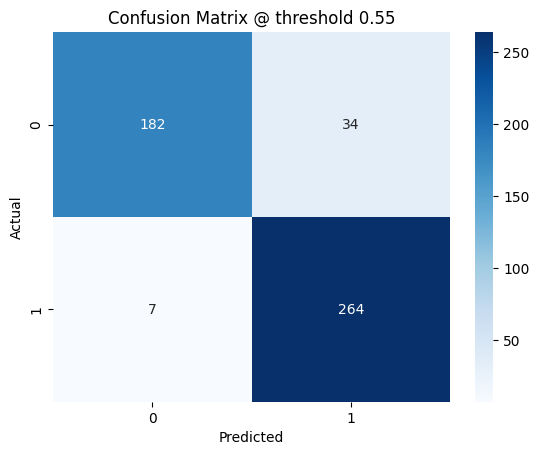

              precision    recall  f1-score   support

           0       0.96      0.84      0.90       216
           1       0.89      0.97      0.93       271

    accuracy                           0.92       487
   macro avg       0.92      0.91      0.91       487
weighted avg       0.92      0.92      0.92       487


Threshold: 0.6


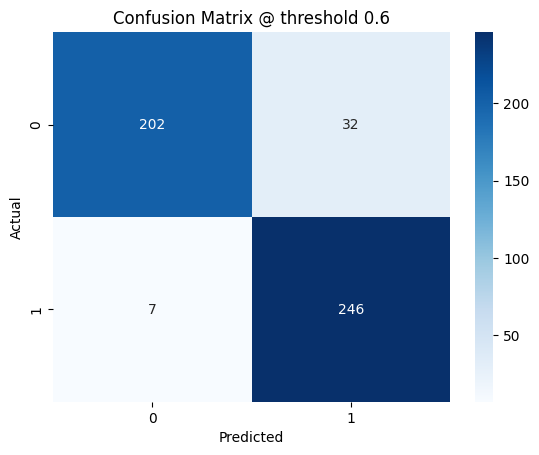

              precision    recall  f1-score   support

           0       0.97      0.86      0.91       234
           1       0.88      0.97      0.93       253

    accuracy                           0.92       487
   macro avg       0.93      0.92      0.92       487
weighted avg       0.92      0.92      0.92       487


Threshold: 0.65


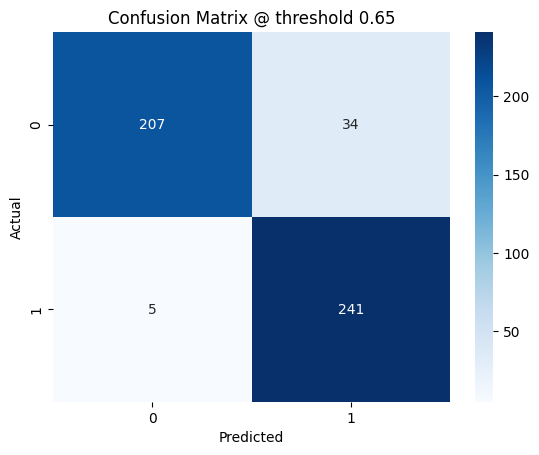

              precision    recall  f1-score   support

           0       0.98      0.86      0.91       241
           1       0.88      0.98      0.93       246

    accuracy                           0.92       487
   macro avg       0.93      0.92      0.92       487
weighted avg       0.93      0.92      0.92       487


Threshold: 0.7


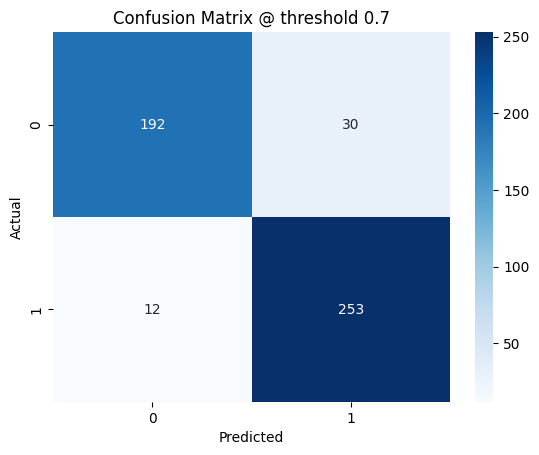

              precision    recall  f1-score   support

           0       0.94      0.86      0.90       222
           1       0.89      0.95      0.92       265

    accuracy                           0.91       487
   macro avg       0.92      0.91      0.91       487
weighted avg       0.92      0.91      0.91       487



In [54]:
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]

for t in thresholds:

    y_true = []  
    y_pred = []

    for imgs, labels in test_ds:
        preds = models[2].predict(imgs, verbose=0)
        preds = preds.ravel()  # ✅ IMPORTANT

        y_true.extend(labels.numpy())
        y_pred.extend((preds >= t).astype(int))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    cm = confusion_matrix(y_true, y_pred)

    print(f"\nThreshold: {t}")
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix @ threshold {t}")
    plt.show()

    print(classification_report(y_true, y_pred))



Threshold: 0.3


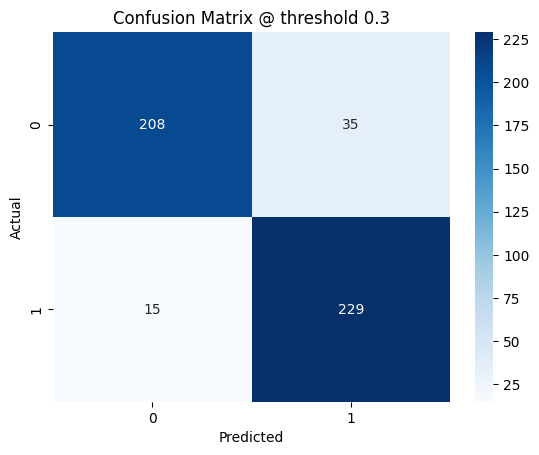

              precision    recall  f1-score   support

           0       0.93      0.86      0.89       243
           1       0.87      0.94      0.90       244

    accuracy                           0.90       487
   macro avg       0.90      0.90      0.90       487
weighted avg       0.90      0.90      0.90       487


Threshold: 0.35


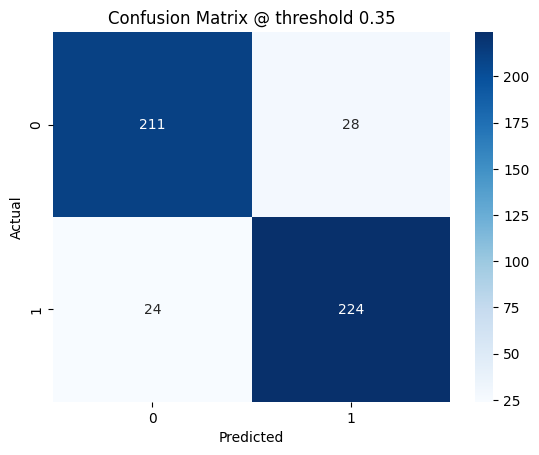

              precision    recall  f1-score   support

           0       0.90      0.88      0.89       239
           1       0.89      0.90      0.90       248

    accuracy                           0.89       487
   macro avg       0.89      0.89      0.89       487
weighted avg       0.89      0.89      0.89       487


Threshold: 0.4


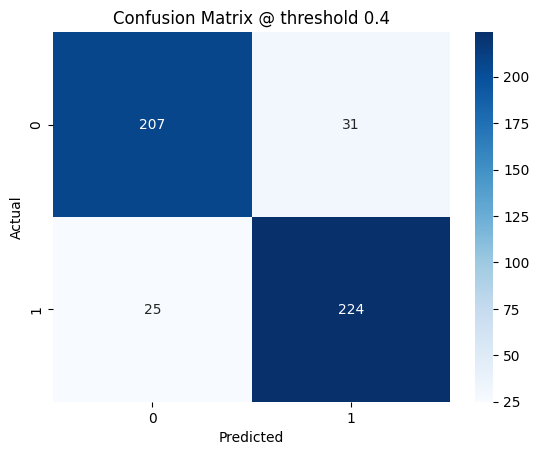

              precision    recall  f1-score   support

           0       0.89      0.87      0.88       238
           1       0.88      0.90      0.89       249

    accuracy                           0.89       487
   macro avg       0.89      0.88      0.88       487
weighted avg       0.89      0.89      0.88       487


Threshold: 0.45


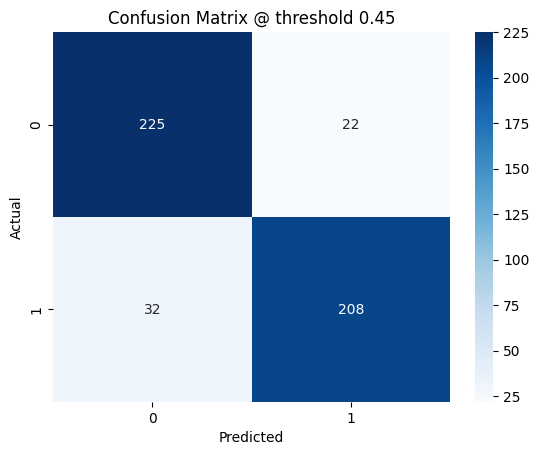

              precision    recall  f1-score   support

           0       0.88      0.91      0.89       247
           1       0.90      0.87      0.89       240

    accuracy                           0.89       487
   macro avg       0.89      0.89      0.89       487
weighted avg       0.89      0.89      0.89       487


Threshold: 0.5


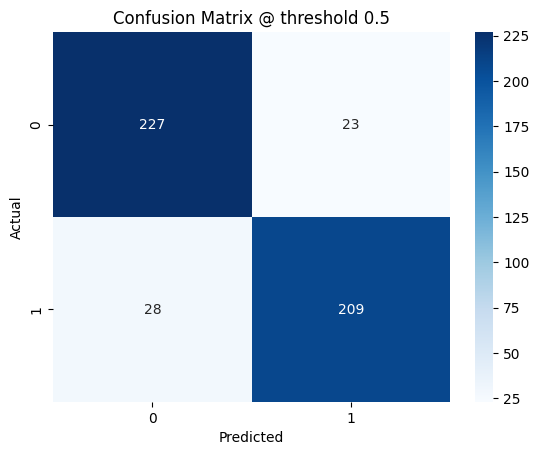

              precision    recall  f1-score   support

           0       0.89      0.91      0.90       250
           1       0.90      0.88      0.89       237

    accuracy                           0.90       487
   macro avg       0.90      0.89      0.90       487
weighted avg       0.90      0.90      0.90       487


Threshold: 0.55


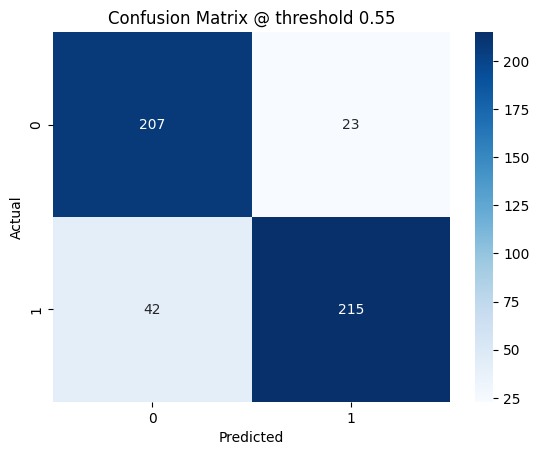

              precision    recall  f1-score   support

           0       0.83      0.90      0.86       230
           1       0.90      0.84      0.87       257

    accuracy                           0.87       487
   macro avg       0.87      0.87      0.87       487
weighted avg       0.87      0.87      0.87       487


Threshold: 0.6


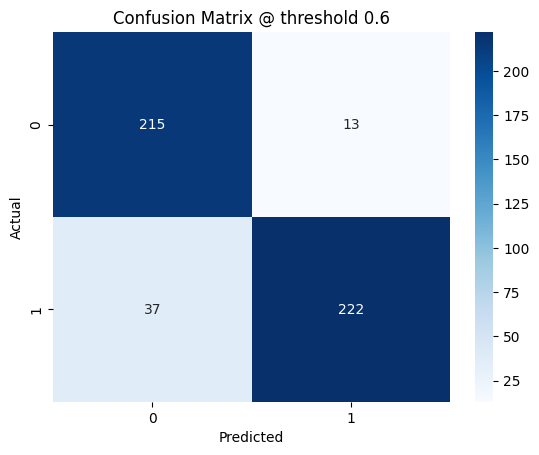

              precision    recall  f1-score   support

           0       0.85      0.94      0.90       228
           1       0.94      0.86      0.90       259

    accuracy                           0.90       487
   macro avg       0.90      0.90      0.90       487
weighted avg       0.90      0.90      0.90       487


Threshold: 0.65


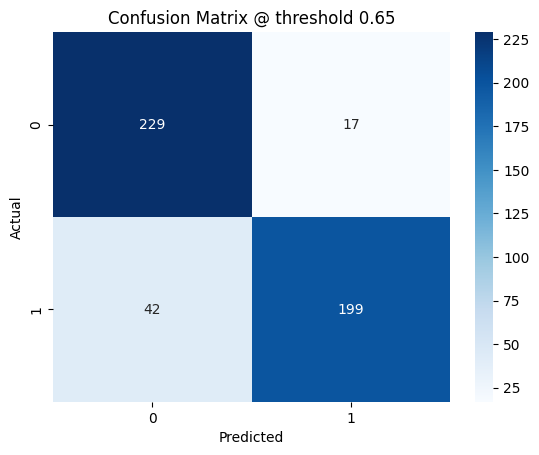

              precision    recall  f1-score   support

           0       0.85      0.93      0.89       246
           1       0.92      0.83      0.87       241

    accuracy                           0.88       487
   macro avg       0.88      0.88      0.88       487
weighted avg       0.88      0.88      0.88       487


Threshold: 0.7


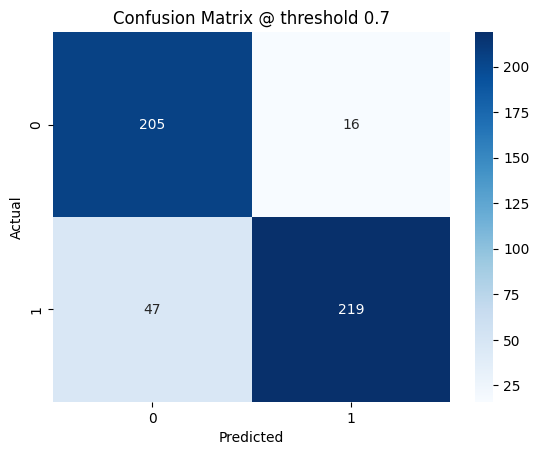

              precision    recall  f1-score   support

           0       0.81      0.93      0.87       221
           1       0.93      0.82      0.87       266

    accuracy                           0.87       487
   macro avg       0.87      0.88      0.87       487
weighted avg       0.88      0.87      0.87       487



In [55]:
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]

for t in thresholds:

    y_true = []  
    y_pred = []

    for imgs, labels in test_ds:
        preds = models[3].predict(imgs, verbose=0)
        preds = preds.ravel()  # ✅ IMPORTANT

        y_true.extend(labels.numpy())
        y_pred.extend((preds >= t).astype(int))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    cm = confusion_matrix(y_true, y_pred)

    print(f"\nThreshold: {t}")
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix @ threshold {t}")
    plt.show()

    print(classification_report(y_true, y_pred))



Threshold: 0.3


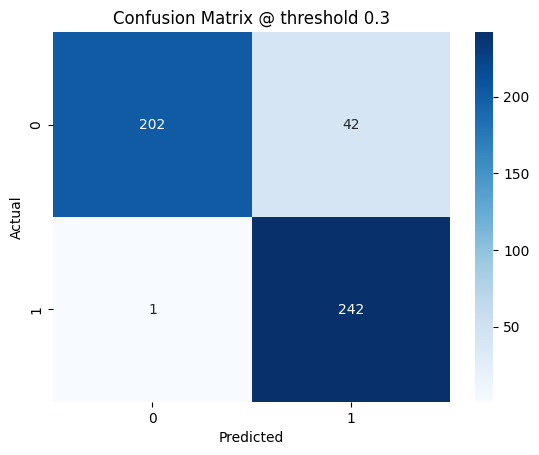

              precision    recall  f1-score   support

           0       1.00      0.83      0.90       244
           1       0.85      1.00      0.92       243

    accuracy                           0.91       487
   macro avg       0.92      0.91      0.91       487
weighted avg       0.92      0.91      0.91       487


Threshold: 0.35


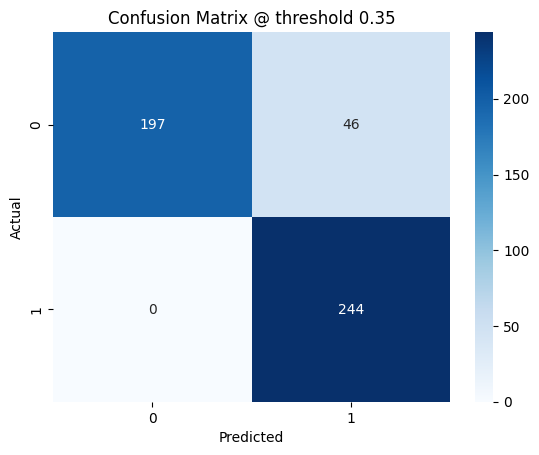

              precision    recall  f1-score   support

           0       1.00      0.81      0.90       243
           1       0.84      1.00      0.91       244

    accuracy                           0.91       487
   macro avg       0.92      0.91      0.90       487
weighted avg       0.92      0.91      0.90       487


Threshold: 0.4


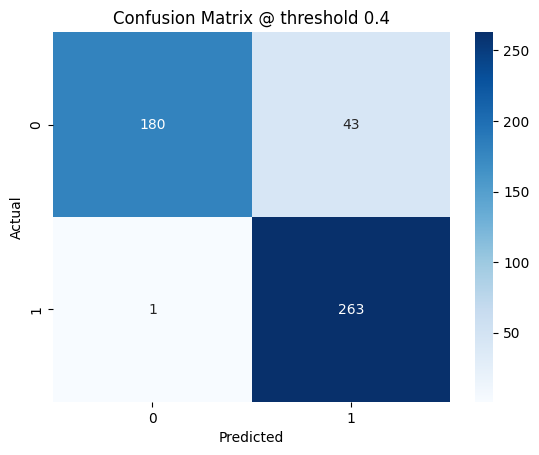

              precision    recall  f1-score   support

           0       0.99      0.81      0.89       223
           1       0.86      1.00      0.92       264

    accuracy                           0.91       487
   macro avg       0.93      0.90      0.91       487
weighted avg       0.92      0.91      0.91       487


Threshold: 0.45


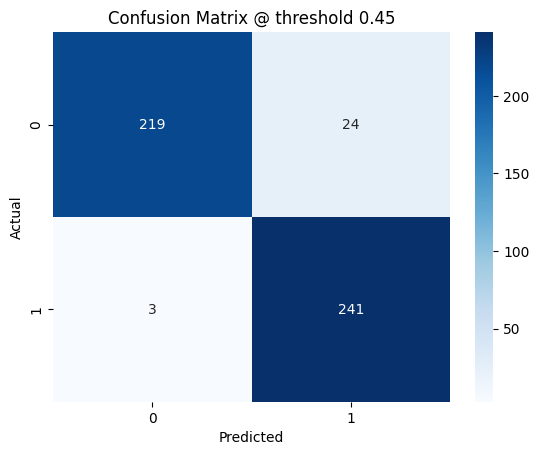

              precision    recall  f1-score   support

           0       0.99      0.90      0.94       243
           1       0.91      0.99      0.95       244

    accuracy                           0.94       487
   macro avg       0.95      0.94      0.94       487
weighted avg       0.95      0.94      0.94       487


Threshold: 0.5


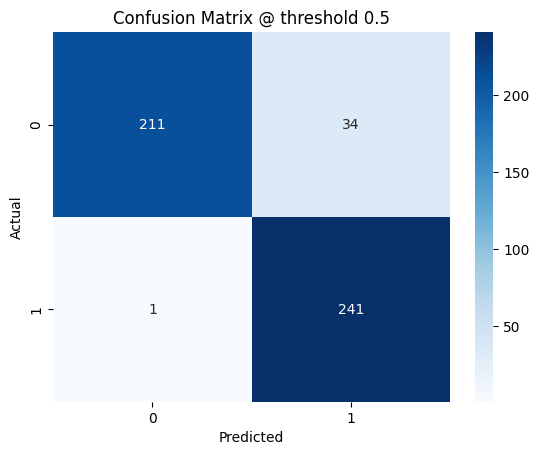

              precision    recall  f1-score   support

           0       1.00      0.86      0.92       245
           1       0.88      1.00      0.93       242

    accuracy                           0.93       487
   macro avg       0.94      0.93      0.93       487
weighted avg       0.94      0.93      0.93       487


Threshold: 0.55


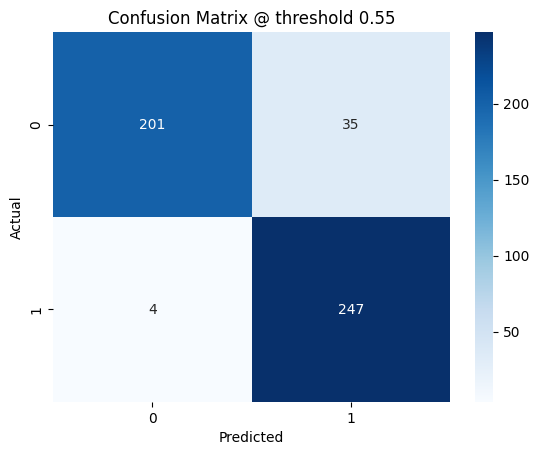

              precision    recall  f1-score   support

           0       0.98      0.85      0.91       236
           1       0.88      0.98      0.93       251

    accuracy                           0.92       487
   macro avg       0.93      0.92      0.92       487
weighted avg       0.93      0.92      0.92       487


Threshold: 0.6


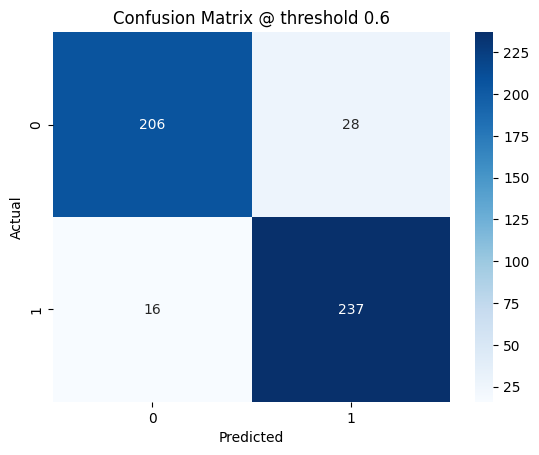

              precision    recall  f1-score   support

           0       0.93      0.88      0.90       234
           1       0.89      0.94      0.92       253

    accuracy                           0.91       487
   macro avg       0.91      0.91      0.91       487
weighted avg       0.91      0.91      0.91       487


Threshold: 0.65


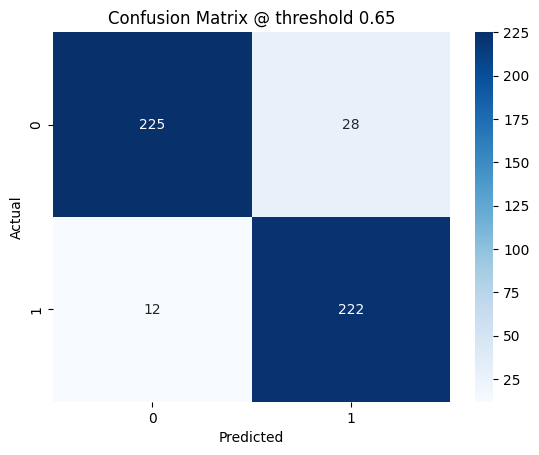

              precision    recall  f1-score   support

           0       0.95      0.89      0.92       253
           1       0.89      0.95      0.92       234

    accuracy                           0.92       487
   macro avg       0.92      0.92      0.92       487
weighted avg       0.92      0.92      0.92       487


Threshold: 0.7


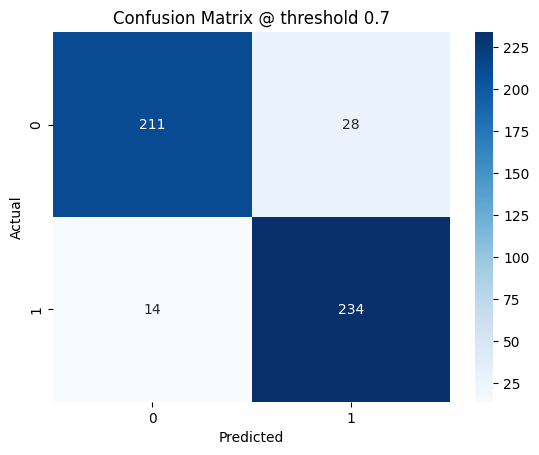

              precision    recall  f1-score   support

           0       0.94      0.88      0.91       239
           1       0.89      0.94      0.92       248

    accuracy                           0.91       487
   macro avg       0.92      0.91      0.91       487
weighted avg       0.92      0.91      0.91       487



In [57]:
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]

for t in thresholds:

    y_true = []  
    y_pred = []

    for imgs, labels in test_ds:
        preds = models[4].predict(imgs, verbose=0)
        preds = preds.ravel()  # ✅ IMPORTANT

        y_true.extend(labels.numpy())
        y_pred.extend((preds >= t).astype(int))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    cm = confusion_matrix(y_true, y_pred)

    print(f"\nThreshold: {t}")
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix @ threshold {t}")
    plt.show()

    print(classification_report(y_true, y_pred))


In [60]:
def build_ensemble_model(models, weights):
    inputs = tf.keras.Input(shape=(224, 224, 3))

    outputs = []
    for model in models:
        model.trainable = False
        outputs.append(model(inputs))

    weighted_outputs = [
        outputs[i] * weights[i] for i in range(len(outputs))
    ]

    avg_output = tf.keras.layers.Add()(weighted_outputs)

    return tf.keras.Model(inputs=inputs, outputs=avg_output)


In [62]:
weights = np.array([1.0, 1.0, 1.2, 1.0, 1.5])
weights = weights / weights.sum()

ensemble_model = build_ensemble_model(models, weights)
ensemble_model.save("final_ensemble_model.h5")


In [63]:
ensemble_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_5        │ (None, 1)         │ 10,101,377 │ input_layer_15[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_6        │ (None, 1)         │ 10,101,377 │ input_layer_15[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_7        │ (None, 1)         │ 10,101,377 │ input_layer_15[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_8        │ (None, 1)         │ 10,101,377 │ input_layer_15[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_9        │ (None, 1)         │ 10,101,377 │ input_layer_15[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_10         │ (None, 1)         │          0 │ sequential_5[2][… │
│ (Multiply)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_11         │ (None, 1)         │          0 │ sequential_6[2][… │
│ (Multiply)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_12         │ (None, 1)         │          0 │ sequential_7[2][… │
│ (Multiply)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_13         │ (None, 1)         │          0 │ sequential_8[2][… │
│ (Multiply)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_14         │ (None, 1)         │          0 │ sequential_9[2][… │
│ (Multiply)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 1)         │          0 │ multiply_10[0][0… │
│                     │                   │            │ multiply_11[0][0… │
│                     │                   │            │ multiply_12[0][0… │
│                     │                   │            │ multiply_13[0][0… │
│                     │                   │            │ multiply_14[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 50,506,885 (192.67 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 50,506,885 (192.67 MB)


Threshold: 0.3


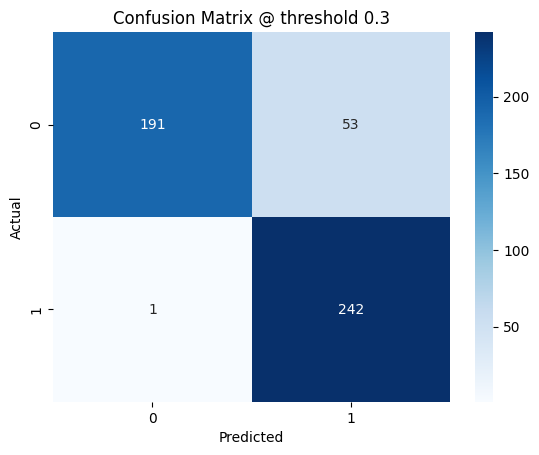

              precision    recall  f1-score   support

           0       0.99      0.78      0.88       244
           1       0.82      1.00      0.90       243

    accuracy                           0.89       487
   macro avg       0.91      0.89      0.89       487
weighted avg       0.91      0.89      0.89       487


Threshold: 0.35


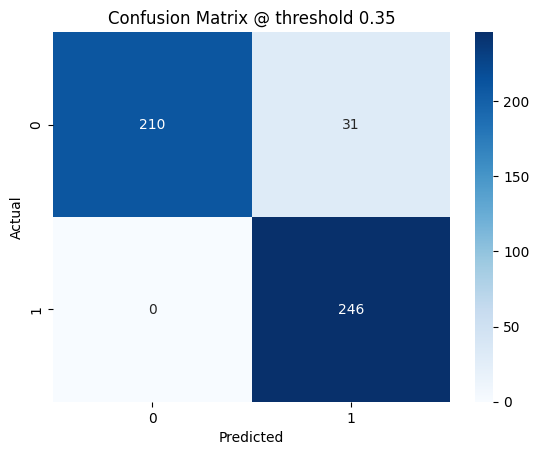

              precision    recall  f1-score   support

           0       1.00      0.87      0.93       241
           1       0.89      1.00      0.94       246

    accuracy                           0.94       487
   macro avg       0.94      0.94      0.94       487
weighted avg       0.94      0.94      0.94       487


Threshold: 0.4


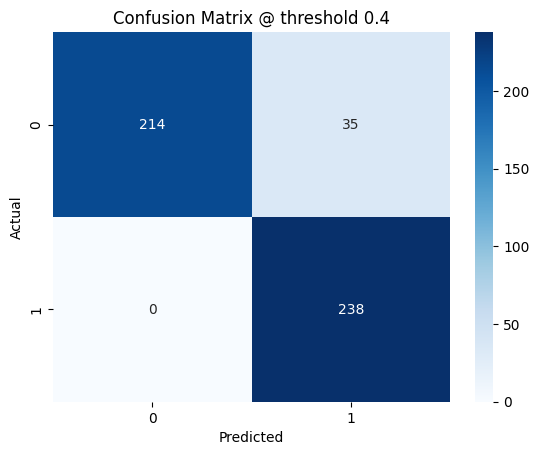

              precision    recall  f1-score   support

           0       1.00      0.86      0.92       249
           1       0.87      1.00      0.93       238

    accuracy                           0.93       487
   macro avg       0.94      0.93      0.93       487
weighted avg       0.94      0.93      0.93       487


Threshold: 0.45


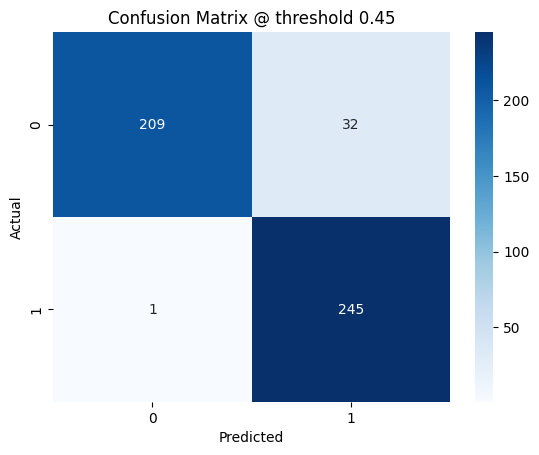

              precision    recall  f1-score   support

           0       1.00      0.87      0.93       241
           1       0.88      1.00      0.94       246

    accuracy                           0.93       487
   macro avg       0.94      0.93      0.93       487
weighted avg       0.94      0.93      0.93       487


Threshold: 0.5


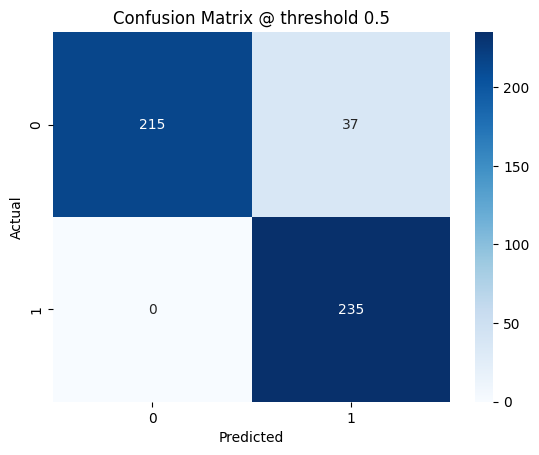

              precision    recall  f1-score   support

           0       1.00      0.85      0.92       252
           1       0.86      1.00      0.93       235

    accuracy                           0.92       487
   macro avg       0.93      0.93      0.92       487
weighted avg       0.93      0.92      0.92       487


Threshold: 0.55


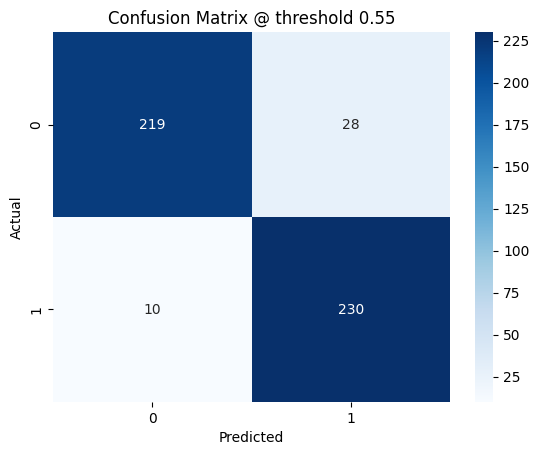

              precision    recall  f1-score   support

           0       0.96      0.89      0.92       247
           1       0.89      0.96      0.92       240

    accuracy                           0.92       487
   macro avg       0.92      0.92      0.92       487
weighted avg       0.92      0.92      0.92       487


Threshold: 0.6


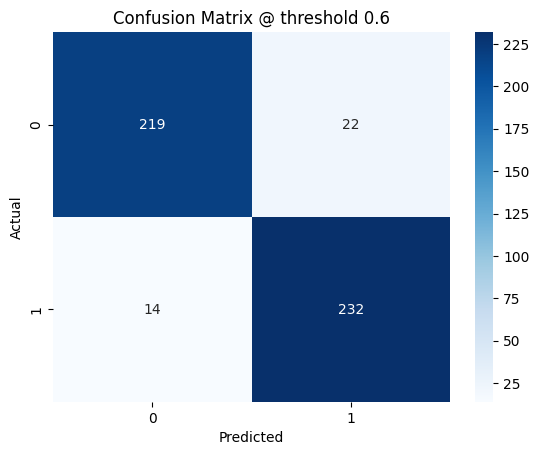

              precision    recall  f1-score   support

           0       0.94      0.91      0.92       241
           1       0.91      0.94      0.93       246

    accuracy                           0.93       487
   macro avg       0.93      0.93      0.93       487
weighted avg       0.93      0.93      0.93       487


Threshold: 0.65


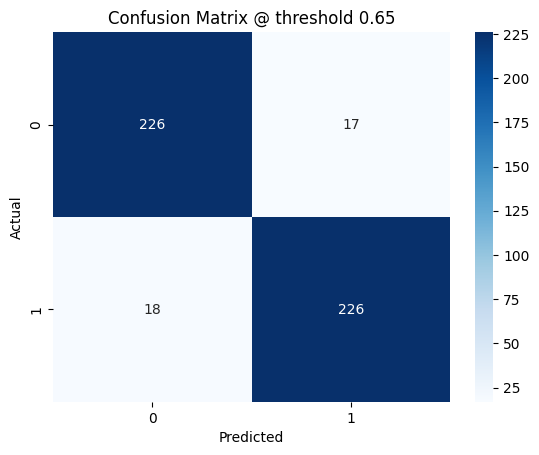

              precision    recall  f1-score   support

           0       0.93      0.93      0.93       243
           1       0.93      0.93      0.93       244

    accuracy                           0.93       487
   macro avg       0.93      0.93      0.93       487
weighted avg       0.93      0.93      0.93       487


Threshold: 0.7


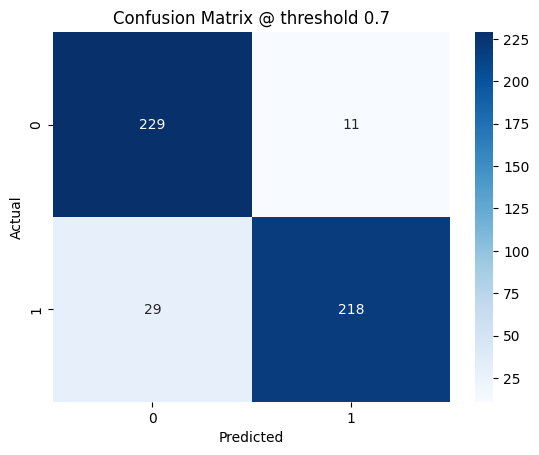

              precision    recall  f1-score   support

           0       0.89      0.95      0.92       240
           1       0.95      0.88      0.92       247

    accuracy                           0.92       487
   macro avg       0.92      0.92      0.92       487
weighted avg       0.92      0.92      0.92       487



In [64]:
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]

for t in thresholds:

    y_true = []  
    y_pred = []

    for imgs, labels in test_ds:
        preds = ensemble_model.predict(imgs, verbose=0)
        preds = preds.ravel()  # ✅ IMPORTANT

        y_true.extend(labels.numpy())
        y_pred.extend((preds >= t).astype(int))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    cm = confusion_matrix(y_true, y_pred)

    print(f"\nThreshold: {t}")
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix @ threshold {t}")
    plt.show()

    print(classification_report(y_true, y_pred))


In [65]:
for m in models:
    m.trainable = False

def se_block(x, ratio=16):
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(filters // ratio, activation="relu")(se)
    se = layers.Dense(filters, activation="sigmoid")(se)
    se = layers.Reshape((1,1,filters))(se)
    return layers.multiply([x, se])


def build_improved_custom_cnn():
    inputs = keras.Input(shape=(224,224,3))

    # Block 1 (Multi-scale)
    x1 = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x2 = layers.Conv2D(32, 5, padding="same", activation="relu")(inputs)
    x = layers.Concatenate()([x1, x2])
    x = se_block(x)
    x = layers.MaxPooling2D()(x)

    # Block 2
    x1 = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x2 = layers.Conv2D(64, 5, padding="same", activation="relu")(x)
    x = layers.Concatenate()([x1, x2])
    x = se_block(x)
    x = layers.MaxPooling2D()(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = se_block(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [66]:
model5 = build_improved_custom_cnn()
model5.summary()

history5 = model5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1
)

model5.save("cnn_model_5_attention_multiscale.h5")


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 224, 224,  │        896 │ input_layer_16[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 224, 224,  │      2,432 │ input_layer_16[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 224, 224,  │          0 │ conv2d_63[0][0],  │
│ (Concatenate)       │ 64)               │            │ conv2d_64[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ concatenate[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 4)         │        260 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 64)        │        320 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 64)  │          0 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_15         │ (None, 224, 224,  │          0 │ concatenate[0][0… │
│ (Multiply)          │ 64)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_28    │ (None, 112, 112,  │          0 │ multiply_15[0][0] │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, 112, 112,  │     36,928 │ max_pooling2d_28… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_66 (Conv2D)  │ (None, 112, 112,  │    102,464 │ max_pooling2d_28… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 112, 112,  │          0 │ conv2d_65[0][0],  │
│ (Concatenate)       │ 128)              │            │ conv2d_66[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ concatenate_1[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 8)         │      1,032 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 128)       │      1,152 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1, 128) │          0 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_16         │ (None, 112, 112,  │          0 │ concatenate_1[0]… │
│ (Multiply)          │ 128)              │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_29    │ (None, 56, 56,    │          0 │ multiply_16[0][0

 Total params: 328,533 (1.25 MB)

 Trainable params: 328,533 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 332s 8s/step - accuracy: 0.5144 - loss: 0.6929 - val_accuracy: 0.5103 - val_loss: 0.6918
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 209s 5s/step - accuracy: 0.5031 - loss: 0.6918 - val_accuracy: 0.5082 - val_loss: 0.6903
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 231s 6s/step - accuracy: 0.5165 - loss: 0.6898 - val_accuracy: 0.4918 - val_loss: 0.6887
Epoch 4/30
 5/41 ━━━━━━━━━━━━━━━━━━━━ 2:40 4s/step - accuracy: 0.4583 - loss: 0.6987

KeyboardInterrupt: 